In [ ]:
# Step 0: Mount Google Drive to Colab

import os
from google.colab import drive

drive.mount('/content/drive')

# Set the root path to a folder inside Drive for datasets and model
gdrive_path = '/content/drive/Othercomputers/My MacBook Pro/AI Job Prep/Phase2_Deep_Learning/Projects/DistilBERT News Classifier/week6_distilbert_news_classifier'

# Create the directory if it doesn't exist
if not os.path.exists(gdrive_path):
    os.makedirs(gdrive_path)
    print(f"Created directory: {gdrive_path}")
else:
    print(f"Directory already exists: {gdrive_path}")

# DistilBERT News Classifier — AG News

Fine-tuning DistilBERT to classify news headlines into World / Sports / Business / Sci-Tech, benchmarked against a TF-IDF + Logistic Regression baseline.

## Phase 1 — Setup & Data Loading

In [2]:
# Step 1: Getting the environment sorted first — installs + W&B login
!pip install transformers datasets wandb scikit-learn -q

# Colab's preinstalled torchvision build is missing torchvision.io.VideoReader, and the
# datasets torch formatter unconditionally probes for it — crashes with ImportError on
# set_format("torch", ...) even though we never touch video. Not needed for this project,
# so pulling it out entirely. Requires Runtime > Restart session after this runs once.
!pip uninstall -y torchvision -q

import wandb
wandb.login()   # will prompt for your API key first time

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: prasanthreddy030 (prasanthreddy030-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
# Step 2: Pulling AG News from the Hub — checking sizes match what's documented

from datasets import load_dataset

# "ag_news" short-name resolution broke on newer datasets/huggingface_hub versions
# (HfUriError: repo id must be 'namespace/name') -- using the full repo id instead
dataset = load_dataset("fancyzhx/ag_news")

print(dataset)
print(f"\n\nTrain size: {len(dataset['train'])}")   # expect 120,000
print(f"Test size:  {len(dataset['test'])}")    # expect 7,600

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


Train size: 120000
Test size:  7600


In [ ]:
# quick sanity check on schema before building anything on top of it
print(dataset['train'][0])
print(dataset['train'].features['label'].names)   # ['World', 'Sports', 'Business', 'Sci/Tech']

In [ ]:
# baseline first — TF-IDF over raw text, no transformer involved yet
from sklearn.feature_extraction.text import TfidfVectorizer

id2label = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
label2id = {v: k for k, v in id2label.items()}

train_texts = dataset['train']['text']
test_texts = dataset['test']['text']
train_labels = dataset['train']['label']
test_labels = dataset['test']['label']

vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

## Phase 2 — TF-IDF Baseline

In [ ]:
import time
from sklearn.linear_model import LogisticRegression

start = time.time()
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train, train_labels)
baseline_train_time = time.time() - start

print(f"Baseline training time: {baseline_train_time:.1f}s")

In [ ]:
# this is the number DistilBERT needs to beat
from sklearn.metrics import accuracy_score, classification_report

lr_preds = lr.predict(X_test)
baseline_accuracy = accuracy_score(test_labels, lr_preds)

print(f"Baseline accuracy: {baseline_accuracy:.4f}\n")
print(classification_report(test_labels, lr_preds, target_names=list(id2label.values())))

In [ ]:
# saving this as a visual reference for the README comparison later
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

figures_dir = os.path.join(gdrive_path, "reports/figures")
os.makedirs(figures_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    test_labels, lr_preds,
    display_labels=list(id2label.values()),
    cmap='Blues', ax=ax, colorbar=False
)

ax.set_title("TF-IDF + Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "baseline_confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
# same checkpoint I'll fine-tune, so tokenization matches what the model expects
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

## Phase 3 — Tokenization

In [10]:
# Step 9a: Writing the tokenize function
# max_length=128 — AG News is title + short description, 128 tokens covers it comfortably

def tokenize_fn(examples):
  return tokenizer(
      examples["text"],
      padding="max_length",
      truncation=True,
      max_length=128
  )

In [11]:
# Step 9b: Applying tokenization across the whole dataset, renaming label -> labels
# Trainer expects the target column to be called "labels", not "label"

tokenized = dataset.map(tokenize_fn, batched=True)
tokenized = tokenized.rename_column("label", "labels")
print(tokenized)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})


In [ ]:
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
print(tokenized["train"][0]["input_ids"].shape)   # expect torch.Size([128])

## Phase 4 — Model

In [13]:
# Step 10: Loading DistilBERT with a 4-class classification head
# num_labels=4 swaps out the default binary head for a fresh 4-way linear layer

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")   # expect ~66M

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 66,956,548


## Phase 5 — TrainingArguments & Trainer

In [14]:
# Step 11a: Setting up TrainingArguments — working through what each one actually does

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert-ag-news",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,              # standard fine-tuning LR for BERT-family models
    weight_decay=0.01,               # AdamW weight decay, ties back to regularization
    lr_scheduler_type="linear",      # linear warmup then linear decay to 0
    warmup_steps=500,                # ~2% of total steps, avoids early instability
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="wandb",
    run_name="distilbert-ag-news-v1",
    logging_steps=100,
)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=1)
  return {"accuracy": accuracy_score(labels, preds)}

In [ ]:
# patience=2 — ties back to the early-stopping theory from earlier weeks
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
train_result = trainer.train()

## Phase 6 — W&B Experiment Logging

In [ ]:
# report_to="wandb" in TrainingArguments handles the logging automatically — just confirming the run's live
print(wandb.run.url)
print(wandb.run.name)

# Step 14: Training curves

Went to the W&B run dashboard (link printed above) and exported the train loss and eval accuracy
charts separately, saved as `reports/figures/Training Loss.png` and
`reports/figures/Evaluation Accuracy.png`. Confirmed loss trends down and accuracy trends up
across the 3 epochs before moving on.

In [ ]:
eval_results = trainer.evaluate()
distilbert_accuracy = eval_results["eval_accuracy"]

print(f"DistilBERT test accuracy: {distilbert_accuracy:.4f}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")

## Phase 7 — Evaluation & Comparison

In [ ]:
bert_preds_logits = trainer.predict(tokenized["test"])
bert_preds = np.argmax(bert_preds_logits.predictions, axis=1)

print(classification_report(test_labels, bert_preds, target_names=list(id2label.values())))

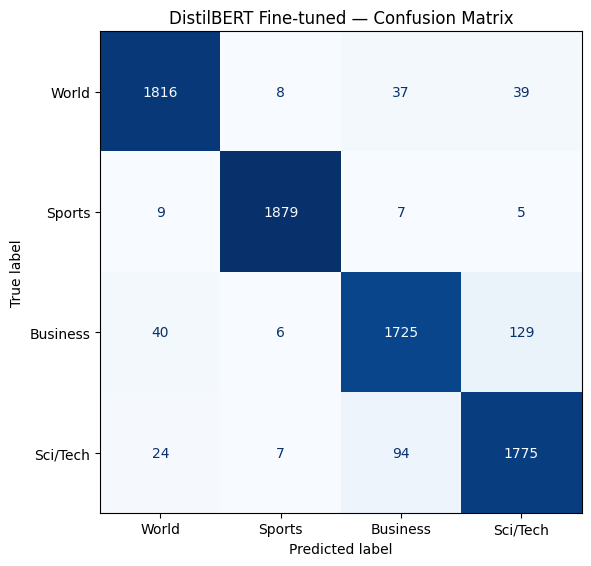

In [25]:
# Step 17: Confusion matrix for DistilBERT, saved next to the baseline one for comparison

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    test_labels, bert_preds,
    display_labels=list(id2label.values()),
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("DistilBERT Fine-tuned — Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "distilbert_confusion_matrix.png"), dpi=150)
plt.show()

In [26]:
# Step 18: Side-by-side comparison — this table goes straight into the README

from sklearn.metrics import f1_score

bert_f1_per_class = f1_score(test_labels, bert_preds, average=None)
lr_f1_per_class = f1_score(test_labels, lr_preds, average=None)

comparison = {
    "Metric": ["Test Accuracy", "World F1", "Sports F1", "Business F1", "Sci/Tech F1", "Training Time"],
    "TF-IDF + LR Baseline": [
        f"{baseline_accuracy:.4f}",
        f"{lr_f1_per_class[0]:.4f}",
        f"{lr_f1_per_class[1]:.4f}",
        f"{lr_f1_per_class[2]:.4f}",
        f"{lr_f1_per_class[3]:.4f}",
        f"{baseline_train_time:.1f}s",
    ],
    "DistilBERT Fine-tuned": [
        f"{distilbert_accuracy:.4f}",
        f"{bert_f1_per_class[0]:.4f}",
        f"{bert_f1_per_class[1]:.4f}",
        f"{bert_f1_per_class[2]:.4f}",
        f"{bert_f1_per_class[3]:.4f}",
        f"{train_result.metrics['train_runtime'] / 60:.1f} min",
    ],
}

import pandas as pd
comparison_df = pd.DataFrame(comparison)
comparison_df

,Metric,TF-IDF + LR Baseline,DistilBERT Fine-tuned
0,Test Accuracy,0.9199,0.9467
1,World F1,0.9215,0.9586
2,Sports F1,0.9666,0.9889
3,Business F1,0.8904,0.9168
4,Sci/Tech F1,0.9003,0.9226
5,Training Time,49.0s,62.6 min


In [27]:
# Step 19: Saving the fine-tuned model + tokenizer locally on the Colab VM first
# (saving straight to Drive can be slow/flaky for many small files — local save then copy is safer)

trainer.save_model("./distilbert-ag-news-final")
tokenizer.save_pretrained("./distilbert-ag-news-final")
print("Model saved locally.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved locally.


## Phase 8 — Save & Back Up Model

In [ ]:
import shutil

drive_model_target = os.path.join(gdrive_path, "models/distilbert-ag-news-final")
shutil.copytree("./distilbert-ag-news-final", drive_model_target, dirs_exist_ok=True)
print(f"Backed up to {drive_model_target}")

## Phase 9 — Reload & Inference Check

In [ ]:
# reloading from disk (not reusing the in-memory model) to prove it actually works standalone
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

reloaded_model = AutoModelForSequenceClassification.from_pretrained("./distilbert-ag-news-final")
reloaded_tokenizer = AutoTokenizer.from_pretrained("./distilbert-ag-news-final")

samples = [
    "NASA announces new mission to explore the outer solar system",
    "LeBron James leads Lakers to victory with a last-second shot",
    "Federal Reserve raises interest rates amid inflation concerns",
]

reloaded_model.eval()
for text in samples:
    inputs = reloaded_tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        logits = reloaded_model(**inputs).logits
    pred_id = logits.argmax(dim=-1).item()
    print(f"{text}\n  -> {id2label[pred_id]}\n")

## Summary

DistilBERT fine-tuned on AG News hits **94.67%** test accuracy, beating the TF-IDF + Logistic
Regression baseline's **91.99%** by ~2.7 points and clearing the ~93% target from the project spec.
Business and Sci/Tech remain the hardest classes for both models — they share vocabulary in a way
World/Sports don't — but DistilBERT closes more of that gap than the baseline can, since it picks up
contextual cues from word order that a bag-of-n-grams representation misses.

Model, tokenizer, and both confusion matrices are saved to `models/` and `reports/figures/`
respectively. Full run details and training curves are in the linked W&B run (Step 13). See the
project README for the complete writeup.